# Notre modèle XG Boost :

## A. Config & importation des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
import pickle

In [ ]:
TRAIN_PATH = '../6.Data/Yann_Process_train.csv'
TEST_PATH  = '../6.Data/Yann_Process_test.csv'
TARGET     = 'target_is_fraud'
ID_COL     = 'customer_id'
TOP_N      = 10       
THRESHOLD  = 0.51
NB_ESTIMATOR = 700
MAX_DEPTH = 4
LEARNING_RATE = 0.02
SAVE_GRAPH = False


train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

## B. Création des nouvelles feature

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  FEATURE ENGINEERING 
# ══════════════════════════════════════════════════════════════════════════════
def build_features(df):
    df = df.copy()
    df['Score_De_Confiance'] = df['ip_risk_z'] - df['device_trust_z']
    df['Score_Risque'] = (
        df['chargebacks_12m'].clip(lower=0)
        + df['failed_payments_6m'].clip(lower=0)
        + df['ip_risk_z'].clip(lower=0)
        + df['support_tickets_90d'].clip(lower=0)
        - df['device_trust_z'].clip(upper=0)
)
    
    df['cb_per_tenure'] = df['chargebacks_12m'] / (df['tenure_months'].abs() + 0.1)
    df['vpn_ip'] = df['is_vpn'] * df['ip_risk_z']
    df['devices_x_vpn'] = df['num_devices_30d'] * df['is_vpn']
    df['nb_chargeback']   = df['chargebacks_12m'] * df['failed_payments_6m']
    return df


FEATURES = [
    'Score_De_Confiance',
    'ip_risk_z',
    'tenure_months',
    'Score_Risque',
    'is_vpn',
    'cb_per_tenure',
    'vpn_ip',
    'failed_payments_6m',
    'num_devices_30d',
    'devices_x_vpn',
    'support_tickets_90d',
]

## C. Entrainement du modèle

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  CHARGEMENT & ENTRAÎNEMENT
# ══════════════════════════════════════════════════════════════════════════════
print("⏳  Chargement des données…")

train = build_features(train)
test  = build_features(test)

X      = train[FEATURES]
y      = train[TARGET]
X_test = test[FEATURES]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("⏳  Entraînement du modèle XGBoost…")
model = xgb.XGBClassifier(
    n_estimators     = NB_ESTIMATOR,
    max_depth        = MAX_DEPTH,
    learning_rate    = LEARNING_RATE,
    scale_pos_weight = 10.6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'aucpr',
    random_state     = 42,
    n_jobs           = -1,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print("✅  Modèle entraîné.")

⏳  Chargement des données…
⏳  Entraînement du modèle XGBoost…
✅  Modèle entraîné.


## D. Explication du modèle

⏳  Calcul des valeurs SHAP…
✅  Valeurs SHAP calculées.
✅  Graphique sauvegardé → shap_dashboard.png


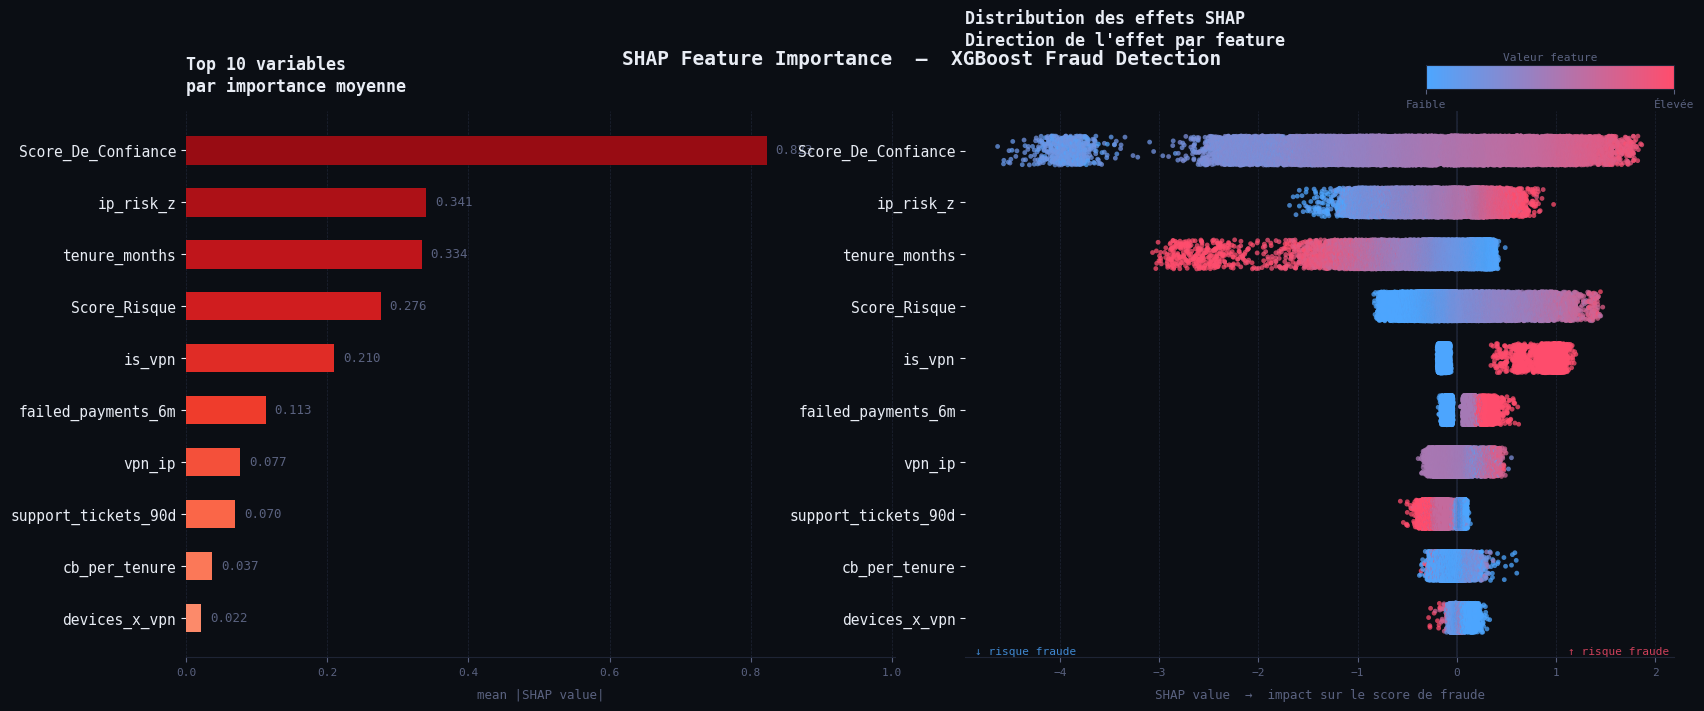

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CALCUL SHAP  (sur le jeu de validation pour la rapidité)
# ══════════════════════════════════════════════════════════════════════════════
print("⏳  Calcul des valeurs SHAP…")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)          # shape (n_samples, n_features)
shap_df     = pd.DataFrame(shap_values, columns=FEATURES)
print("✅  Valeurs SHAP calculées.")

# ── Top-N features par importance moyenne ─────────────────────────────────────
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
top_features  = mean_abs_shap.head(TOP_N).index.tolist()

# ══════════════════════════════════════════════════════════════════════════════
#  PALETTE & STYLE
# ══════════════════════════════════════════════════════════════════════════════
BG      = '#0b0e14'
SURFACE = '#111520'
BORDER  = '#1e2435'
TEXT    = '#e8ecf4'
MUTED   = '#5a6280'
FRAUD   = '#ff4d6d'
SAFE    = '#4da6ff'

plt.rcParams.update({
    'figure.facecolor'  : BG,
    'axes.facecolor'    : BG,
    'axes.edgecolor'    : BORDER,
    'axes.labelcolor'   : MUTED,
    'xtick.color'       : MUTED,
    'ytick.color'       : TEXT,
    'text.color'        : TEXT,
    'grid.color'        : BORDER,
    'grid.linestyle'    : '--',
    'grid.linewidth'    : 0.5,
    'font.family'       : 'monospace',
    'font.size'         : 10,
})

cmap_rb = mcolors.LinearSegmentedColormap.from_list('rb', [SAFE, FRAUD])

# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 7), facecolor=BG)
gs  = GridSpec(1, 2, figure=fig, wspace=0.10, left=0.04, right=0.97,
               top=0.88, bottom=0.10)

# ─────────────────────────────────────────────────────────────────────────────
#  GRAPHIQUE 1 — Bar chart
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(BG)

vals    = mean_abs_shap[top_features].values
labels  = top_features
n       = len(labels)
y_pos   = np.arange(n)

# Dégradé couleur barre : de rouge vif (top) à rouge sombre (bas)
bar_colors = [plt.cm.Reds(0.9 - 0.5 * i / (n - 1)) for i in range(n)]

bars = ax1.barh(y_pos, vals, color=bar_colors, height=0.55, zorder=3)

# Valeurs au bout des barres
for i, (bar, v) in enumerate(zip(bars, vals)):
    ax1.text(v + max(vals) * 0.015, i, f'{v:.3f}',
             va='center', ha='left', color=MUTED, fontsize=9)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=10.5, color=TEXT)
ax1.set_xlabel('mean |SHAP value|', color=MUTED, fontsize=9, labelpad=8)
ax1.set_title('Top 10 variables\npar importance moyenne', color=TEXT,
              fontsize=12, fontweight='bold', pad=14, loc='left')
ax1.xaxis.grid(True, zorder=0)
ax1.set_axisbelow(True)
ax1.invert_yaxis()
ax1.tick_params(axis='x', colors=MUTED, labelsize=8)
ax1.spines[['top','right','left']].set_visible(False)
ax1.spines['bottom'].set_color(BORDER)
ax1.set_xlim(0, max(vals) * 1.22)

# ─────────────────────────────────────────────────────────────────────────────
#  GRAPHIQUE 2 — Beeswarm
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(BG)

# Normalise les valeurs de features pour la couleur (0 → bleu, 1 → rouge)
X_val_reset = X_val.reset_index(drop=True)

for i, feat in enumerate(top_features):
    shap_col = shap_df[feat].values
    feat_col = X_val_reset[feat].values

    # Normalise feature value entre 0 et 1
    fmin, fmax = feat_col.min(), feat_col.max()
    feat_norm  = (feat_col - fmin) / (fmax - fmin + 1e-9)

    colors_pts = cmap_rb(feat_norm)

    # Jitter vertical pour lisibilité (beeswarm simplifié)
    n_pts  = len(shap_col)
    jitter = np.random.default_rng(i).uniform(-0.28, 0.28, n_pts)

    # Tri par shap pour réduire les chevauchements
    order  = np.argsort(shap_col)
    ax2.scatter(
        shap_col[order],
        i + jitter[order],
        c=colors_pts[order],
        s=12, alpha=0.75, linewidths=0, zorder=3
    )

# Ligne zéro
ax2.axvline(0, color=BORDER, linewidth=1.2, zorder=2)

ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features, fontsize=10.5, color=TEXT)
ax2.set_xlabel('SHAP value  →  impact sur le score de fraude', color=MUTED,
               fontsize=9, labelpad=8)
ax2.set_title('Distribution des effets SHAP\nDirection de l\'effet par feature', color=TEXT,
              fontsize=12, fontweight='bold', pad=14, loc='left')
ax2.xaxis.grid(True, zorder=0)
ax2.set_axisbelow(True)
ax2.invert_yaxis()
ax2.tick_params(axis='x', colors=MUTED, labelsize=8)
ax2.spines[['top','right','left']].set_visible(False)
ax2.spines['bottom'].set_color(BORDER)

# Colorbar
cax = ax2.inset_axes([0.65, 1.04, 0.35, 0.045])
cb  = ColorbarBase(cax, cmap=cmap_rb, orientation='horizontal',
                   norm=mcolors.Normalize(0, 1))
cb.set_ticks([0, 1])
cb.set_ticklabels(['Faible', 'Élevée'], fontsize=8, color=MUTED)
cb.outline.set_edgecolor(BORDER)
cax.set_title('Valeur feature', fontsize=8, color=MUTED, pad=3)

# Annotations ↑↓ fraude
xlim = ax2.get_xlim()
ax2.text(xlim[1] * 0.98, len(top_features) - 0.3,
         '↑ risque fraude', color=FRAUD, fontsize=8, ha='right', alpha=0.8)
ax2.text(xlim[0] * 0.98, len(top_features) - 0.3,
         '↓ risque fraude', color=SAFE,  fontsize=8, ha='left',  alpha=0.8)

# ─────────────────────────────────────────────────────────────────────────────
#  TITRE GLOBAL
# ─────────────────────────────────────────────────────────────────────────────
fig.suptitle('SHAP Feature Importance  —  XGBoost Fraud Detection',
             fontsize=14, fontweight='bold', color=TEXT, y=0.97)

if SAVE_GRAPH :
    plt.savefig('shap_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
    print("✅  Graphique sauvegardé → shap_dashboard.png")
plt.show()

## E. Prédiction

In [7]:
y_prob_val = model.predict_proba(X_val)[:, 1]
y_pred_val = (y_prob_val >= THRESHOLD).astype(int)
repport = classification_report(
    y_val,
    y_pred_val,
    output_dict=True
)

y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= THRESHOLD).astype(int)
f1 = f1_score(y_val, y_pred_val)


submission = pd.DataFrame({
    ID_COL:              test[ID_COL],
    TARGET:              y_test_pred,
})

print(f"F1-score : {f1:.4f}")
submission.to_csv('../7.Submission/submission.csv', index=False)
print(f"Submission -> {submission[TARGET].sum()} fraudes | {submission[TARGET].mean()*100:.2f}% du test")

F1-score : 0.3513
Submission -> 11292 fraudes | 28.23% du test


# F. Enregistrer le modèle

In [8]:
with open("../4.Models/XG_Boost_final.pkl", "wb") as f:
    pickle.dump(model, f)

---


# Annexes

# 1. Importance des collones 

In [ ]:
import pandas as pd
import numpy as np
import optuna
import shap
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    f1_score,
    average_precision_score,
)
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

# =========================
# 1️⃣ Chargement des données
# =========================

train = pd.read_csv('../6.Data/Yann_Process_train.csv')
test  = pd.read_csv('../6.Data/Yann_Process_test.csv')

train = train.drop(columns="account_age_days")
test  = test.drop(columns="account_age_days")

target = 'target_is_fraud'
id_col = 'customer_id'

selected_features = [col for col in train.columns if col not in [target, id_col]]

# =========================
# 2️⃣ Feature Engineering
# =========================

def feature_engineering(df):
    df = df.copy()

    # Risque technique device/IP
    df['device_ip_risk']      = df['ip_risk_z'] - df['device_trust_z']

    # Historique de problèmes
    df['trouble_score']       = (df['chargebacks_12m']
                                 + df['failed_payments_6m']
                                 + df['support_tickets_90d'])


    # Score de risque global
    df['global_risk']         = (df['ip_risk_z'] + df['trouble_score']) * (1 - df['device_trust_z'])

    # Interactions
    df['risk_x_trouble']      = df['ip_risk_z'] * df['trouble_score']

    return df


train = feature_engineering(train)
test  = feature_engineering(test)

# Mise à jour des features après engineering
selected_features = [col for col in train.columns if col not in [target, id_col]]

X       = train[selected_features]
y       = train[target]
X_test  = test[selected_features]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =========================
# 3️⃣ Gestion déséquilibre
# =========================

scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight : {scale:.2f}")

# =========================
# 4️⃣ Optimisation Optuna (objectif = F1)
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'scale_pos_weight':  scale,
        'random_state':      42,
        'n_jobs':            -1,
        'eval_metric':       'aucpr',
        'use_label_encoder': False,
    }

    model = XGBClassifier(**params)

    # Scoring F1 en cross-validation (seuil 0.5 par défaut ici,
    # affiné au step 5 sur le jeu de validation)
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()


study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nMeilleurs paramètres : {study.best_params}")
print(f"Meilleur F1 CV       : {study.best_value:.4f}")

# =========================
# 5️⃣ Entraînement final + Early Stopping
# =========================

best_params = study.best_params.copy()
n_est = best_params.pop('n_estimators')

final_model = XGBClassifier(
    **best_params,
    n_estimators=1000,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',
    early_stopping_rounds=50,   # ← déplacé ici dans le constructeur
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"\nNombre d'arbres retenus : {final_model.best_iteration}")

# =========================
# 6️⃣ Recherche du meilleur seuil (max F1 sur validation)
# =========================

y_proba = final_model.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)

f1_scores = (2 * precisions[:-1] * recalls[:-1]
             / (precisions[:-1] + recalls[:-1] + 1e-9))

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nMeilleur seuil (F1 max) : {best_threshold:.3f}")
print(f"Meilleur F1-score       : {f1_scores[best_idx]:.4f}")

# =========================
# 7️⃣ Évaluation finale
# =========================

y_pred = (y_proba >= best_threshold).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

print(f"\nAverage Precision Score : {average_precision_score(y_val, y_proba):.4f}")
print(f"F1 final (val)          : {f1_score(y_val, y_pred):.4f}")

# =========================
# 8️⃣ Analyse SHAP (top features)
# =========================

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_val)
print("\nTop 10 features (SHAP):")
shap.summary_plot(shap_values, X_val, max_display=10, plot_type='bar')

# =========================
# 9️⃣ Prédictions finales sur le test
# =========================

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= best_threshold).astype(int)

submission = pd.DataFrame({
    id_col:          test[id_col],
    'proba_fraud':   test_proba,
    target:          test_pred,
})

submission.to_csv('../6.Data/submission.csv', index=False)
print("\nSubmission sauvegardée → ../6.Data/submission.csv")
print(submission[target].value_counts())

# 2. Trouver les paramètres optimal

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import f1_score

TARGET = 'target_is_fraud'
ID_COL = 'customer_id'

train = pd.read_csv('../6.Data/Yann_Process_train.csv')
test  = pd.read_csv('../6.Data/Yann_Process_test.csv')

def build_features(df):
    df = df.copy()
    df['ip_risk_minus_device_trust'] = df['ip_risk_z'] - df['device_trust_z']
    df['raw_risk_score'] = (
        df['chargebacks_12m'].clip(lower=0)
        + df['failed_payments_6m'].clip(lower=0)
        + df['ip_risk_z'].clip(lower=0)
        + df['support_tickets_90d'].clip(lower=0)
        - df['device_trust_z'].clip(upper=0)
)
    
    df['cb_per_tenure'] = df['chargebacks_12m'] / (df['tenure_months'].abs() + 0.1)
    df['vpn_x_ip_risk'] = df['is_vpn'] * df['ip_risk_z']
    df['devices_x_vpn'] = df['num_devices_30d'] * df['is_vpn']
    df['cb_x_failed']   = df['chargebacks_12m'] * df['failed_payments_6m']
    return df

train = build_features(train)
test  = build_features(test)

FEATURES = [
    'ip_risk_minus_device_trust',
    'ip_risk_z',
    'tenure_months',
    'raw_risk_score',
    'is_vpn',
    'cb_per_tenure',
    'vpn_x_ip_risk',
    'failed_payments_6m',
    'num_devices_30d',
    'devices_x_vpn',
    'support_tickets_90d',
]

X      = train[FEATURES]
y      = train[TARGET]
X_test = test[FEATURES]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


dico = {}
i = 0
for n in [600, 700, 800]:
    for max in [2, 4, 6, 8]:
        for test in ['logloss', 'auc', 'error']:
            for thre in [0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8]:
                model = xgb.XGBClassifier(
                    n_estimators          = n,
                    max_depth             = max,
                    learning_rate         = 0.02,
                    scale_pos_weight      = 10.6,
                    subsample             = 0.8,
                    colsample_bytree      = 0.8,
                    eval_metric           = test,
                    random_state          = 42,
                    n_jobs                = -1,
                )
                model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

                THRESHOLD = thre
                y_prob_val = model.predict_proba(X_val)[:, 1]
                y_pred_val = (y_prob_val >= THRESHOLD).astype(int)
                repport = classification_report(
                    y_val,
                    y_pred_val,
                    output_dict=True
                )

                y_test_prob = model.predict_proba(X_test)[:, 1]
                y_test_pred = (y_test_prob >= THRESHOLD).astype(int)
                f1 = f1_score(y_val, y_pred_val)
                print(f"id: {i} |Eval Metric: {test} | Threshold: {thre} | F1-score : {f1:.4f}")


                dico[i] = {
                    "eval_metric": test,
                    "threshold": thre,
                    "precision": round(repport["1"]["precision"], 4),
                    "recall":    round(repport["1"]["recall"], 4),
                    "f1_score":  round(repport["1"]["f1-score"], 4)
                }
                i += 1


print(dico)


# 3. Modele AI avancé

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, fbeta_score, classification_report
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
TARGET   = 'target_is_fraud'
ID_COL   = 'customer_id'
N_TRIALS = 200
N_SPLITS = 5
SEED     = 42
BETA     = 2  # F2 → favorise le recall

# ─────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────
train = pd.read_csv('../6.Data/Yann_Process_train.csv')
test  = pd.read_csv('../6.Data/Yann_Process_test.csv')

# ─────────────────────────────────────────
# FEATURE ENGINEERING
# ─────────────────────────────────────────
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['ip_risk_minus_device_trust'] = df['ip_risk_z'] - df['device_trust_z']
    df['raw_risk_score'] = (
        df['chargebacks_12m'].clip(lower=0)
        + df['failed_payments_6m'].clip(lower=0)
        + df['ip_risk_z'].clip(lower=0)
        + df['support_tickets_90d'].clip(lower=0)
        - df['device_trust_z'].clip(upper=0)
    )
    df['cb_per_tenure']         = df['chargebacks_12m'] / (df['tenure_months'].abs() + 0.1)
    df['vpn_x_ip_risk']         = df['is_vpn'] * df['ip_risk_z']
    df['devices_x_vpn']         = df['num_devices_30d'] * df['is_vpn']
    df['cb_x_failed']           = df['chargebacks_12m'] * df['failed_payments_6m']
    df['failed_x_ip_risk']      = df['failed_payments_6m'] * df['ip_risk_z']
    df['tickets_x_chargebacks'] = df['support_tickets_90d'] * df['chargebacks_12m']
    df['risk_per_transaction']  = df['raw_risk_score'] / (df['num_transactions_30d'].abs() + 1)
    df['multi_device_vpn']      = (df['num_devices_30d'] > 2).astype(int) * df['is_vpn']
    df['cb_x_ip_risk']          = df['chargebacks_12m'] * df['ip_risk_z']
    df['failed_x_devices']      = df['failed_payments_6m'] * df['num_devices_30d']
    df['total_risk_signals']    = (
        (df['chargebacks_12m'] > 0).astype(int)
        + (df['failed_payments_6m'] > 0).astype(int)
        + df['is_vpn']
        + (df['ip_risk_z'] > 1).astype(int)
        + (df['num_devices_30d'] > 2).astype(int)
    )
    return df

train = build_features(train)
test  = build_features(test)

FEATURES = [
    'ip_risk_minus_device_trust', 'ip_risk_z', 'tenure_months',
    'raw_risk_score', 'is_vpn', 'cb_per_tenure', 'vpn_x_ip_risk',
    'failed_payments_6m', 'num_devices_30d', 'devices_x_vpn',
    'support_tickets_90d', 'cb_x_failed', 'failed_x_ip_risk',
    'tickets_x_chargebacks', 'risk_per_transaction', 'multi_device_vpn',
    'cb_x_ip_risk', 'failed_x_devices', 'total_risk_signals',
]

X      = train[FEATURES]
y      = train[TARGET]
X_test = test[FEATURES]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight automatique : {pos_weight:.2f}")
print(f"Fraudes train : {y_train.sum()} / {len(y_train)} ({y_train.mean()*100:.1f}%)")

# ─────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────
def best_threshold(y_true, y_prob, beta=BETA):
    thresholds = np.arange(0.05, 0.95, 0.01)
    scores = [
        fbeta_score(y_true, (y_prob >= t).astype(int), beta=beta, zero_division=0)
        for t in thresholds
    ]
    best_t = thresholds[np.argmax(scores)]
    return best_t, max(scores)

def resample(X, y, method='smotetomek', seed=SEED):
    if method == 'smotetomek':
        return SMOTETomek(random_state=seed).fit_resample(X, y)
    elif method == 'smote':
        return SMOTE(random_state=seed).fit_resample(X, y)
    else:
        return X, y

# ─────────────────────────────────────────
# FOCAL LOSS — signature correcte pour XGBClassifier (sklearn API)
# XGBClassifier attend : obj(y_true: np.ndarray, y_pred: np.ndarray)
# ─────────────────────────────────────────
def make_focal_loss(gamma=2.0, alpha=0.25):
    def focal_obj(y_true: np.ndarray, y_pred: np.ndarray):
        p   = 1.0 / (1.0 + np.exp(-y_pred))
        pt  = np.where(y_true == 1, p, 1.0 - p)
        at  = np.where(y_true == 1, alpha, 1.0 - alpha)
        grad = -at * (1 - pt) ** gamma * (
            gamma * pt * np.log(np.clip(pt, 1e-9, 1.0)) + (1 - pt)
        ) * (y_true - p)
        hess = at * (1 - pt) ** gamma * p * (1 - p) * np.abs(
            gamma * (1 - 2 * p) * np.log(np.clip(pt, 1e-9, 1.0)) + 2 * (1 - pt)
        )
        hess = np.clip(hess, 1e-6, None)
        return grad, hess
    return focal_obj

# ─────────────────────────────────────────
# OPTUNA — XGBoost + Focal Loss
# ─────────────────────────────────────────
print(f"\n🔍 Optimisation Optuna XGBoost ({N_TRIALS} trials, F{BETA})...")

def xgb_objective(trial):
    gamma_fl = trial.suggest_float('gamma_fl', 0.5, 3.0)
    alpha_fl = trial.suggest_float('alpha_fl', 0.1, 0.5)
    smote_m  = trial.suggest_categorical('smote', ['smotetomek', 'smote', 'none'])

    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 1200),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 3),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0, 3),
        'random_state':     SEED,
        'n_jobs':           -1,
    }

    cv        = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    f2_scores = []

    for step, (tr_idx, vl_idx) in enumerate(cv.split(X_train, y_train)):
        Xtr = X_train.iloc[tr_idx]
        Xvl = X_train.iloc[vl_idx]
        ytr = y_train.iloc[tr_idx]
        yvl = y_train.iloc[vl_idx]

        Xtr, ytr = resample(Xtr, ytr, method=smote_m)

        m = xgb.XGBClassifier(
            **params,
            objective=make_focal_loss(gamma_fl, alpha_fl),
        )
        # ⚠️ pas d'eval_set avec focal loss custom (métriques incompatibles)
        m.fit(Xtr, ytr, verbose=False)

        probs = m.predict_proba(Xvl)[:, 1]
        _, f2 = best_threshold(yvl, probs)
        f2_scores.append(f2)

        trial.report(np.mean(f2_scores), step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(f2_scores)

xgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"XGB meilleur F{BETA} CV : {xgb_study.best_value:.4f}")

# ─────────────────────────────────────────
# OPTUNA — LightGBM
# ─────────────────────────────────────────
print(f"\n🔍 Optimisation Optuna LightGBM ({N_TRIALS} trials, F{BETA})...")

def lgb_objective(trial):
    smote_m = trial.suggest_categorical('smote', ['smotetomek', 'smote', 'none'])

    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1200),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 3),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0, 3),
        'is_unbalance':      True,
        'objective':         'binary',
        'random_state':      SEED,
        'n_jobs':            -1,
        'verbose':           -1,
    }

    cv        = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    f2_scores = []

    for step, (tr_idx, vl_idx) in enumerate(cv.split(X_train, y_train)):
        Xtr = X_train.iloc[tr_idx]
        Xvl = X_train.iloc[vl_idx]
        ytr = y_train.iloc[tr_idx]
        yvl = y_train.iloc[vl_idx]

        Xtr, ytr = resample(Xtr, ytr, method=smote_m)

        m = lgb.LGBMClassifier(**params)
        m.fit(Xtr, ytr, eval_set=[(Xvl, yvl)])

        probs = m.predict_proba(Xvl)[:, 1]
        _, f2 = best_threshold(yvl, probs)
        f2_scores.append(f2)

        trial.report(np.mean(f2_scores), step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(f2_scores)

lgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"LGB meilleur F{BETA} CV : {lgb_study.best_value:.4f}")

# ─────────────────────────────────────────
# ENTRAÎNEMENT FINAL
# ─────────────────────────────────────────
print("\n🚀 Entraînement final...")

best_smote_xgb  = xgb_study.best_params.get('smote', 'smotetomek')
best_smote_lgbm = lgb_study.best_params.get('smote', 'smotetomek')
best_gamma_fl   = xgb_study.best_params.get('gamma_fl', 2.0)
best_alpha_fl   = xgb_study.best_params.get('alpha_fl', 0.25)

X_train_xgb,  y_train_xgb  = resample(X_train, y_train, method=best_smote_xgb)
X_train_lgbm, y_train_lgbm = resample(X_train, y_train, method=best_smote_lgbm)
print(f"  XGB  train size : {len(X_train_xgb)} | LGBM train size : {len(X_train_lgbm)}")

xgb_params = {k: v for k, v in xgb_study.best_params.items()
              if k not in ('gamma_fl', 'alpha_fl', 'smote')}

best_xgb = xgb.XGBClassifier(
    **xgb_params,
    objective=make_focal_loss(best_gamma_fl, best_alpha_fl),
    random_state=SEED,
    n_jobs=-1,
)
best_xgb.fit(X_train_xgb, y_train_xgb, verbose=False)

lgb_params = {k: v for k, v in lgb_study.best_params.items() if k != 'smote'}
best_lgbm = lgb.LGBMClassifier(
    **lgb_params,
    is_unbalance=True,
    objective='binary',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
best_lgbm.fit(X_train_lgbm, y_train_lgbm)

# ─────────────────────────────────────────
# ENSEMBLE
# ─────────────────────────────────────────
xgb_w  = xgb_study.best_value
lgbm_w = lgb_study.best_value
total  = xgb_w + lgbm_w

prob_xgb  = best_xgb.predict_proba(X_val)[:, 1]
prob_lgbm = best_lgbm.predict_proba(X_val)[:, 1]
prob_ens  = (xgb_w * prob_xgb + lgbm_w * prob_lgbm) / total

thresh_xgb,  _ = best_threshold(y_val, prob_xgb)
thresh_lgbm, _ = best_threshold(y_val, prob_lgbm)
thresh_ens,  _ = best_threshold(y_val, prob_ens)

f1_xgb  = f1_score(y_val, (prob_xgb  >= thresh_xgb).astype(int))
f1_lgbm = f1_score(y_val, (prob_lgbm >= thresh_lgbm).astype(int))
f1_ens  = f1_score(y_val, (prob_ens  >= thresh_ens).astype(int))

print(f"\n📊 Résultats sur validation :")
print(f"  XGBoost  — F1: {f1_xgb:.4f}  | threshold: {thresh_xgb:.2f}")
print(f"  LightGBM — F1: {f1_lgbm:.4f}  | threshold: {thresh_lgbm:.2f}")
print(f"  Ensemble — F1: {f1_ens:.4f}  | threshold: {thresh_ens:.2f}")

best_f1 = max(f1_xgb, f1_lgbm, f1_ens)
if best_f1 == f1_ens:
    final_prob_val  = prob_ens
    final_threshold = thresh_ens
    label = "Ensemble"
    prob_test_xgb   = best_xgb.predict_proba(X_test)[:, 1]
    prob_test_lgbm  = best_lgbm.predict_proba(X_test)[:, 1]
    final_prob_test = (xgb_w * prob_test_xgb + lgbm_w * prob_test_lgbm) / total
elif best_f1 == f1_xgb:
    final_prob_val  = prob_xgb
    final_threshold = thresh_xgb
    label = "XGBoost"
    final_prob_test = best_xgb.predict_proba(X_test)[:, 1]
else:
    final_prob_val  = prob_lgbm
    final_threshold = thresh_lgbm
    label = "LightGBM"
    final_prob_test = best_lgbm.predict_proba(X_test)[:, 1]

print(f"\n✅ Modèle retenu : {label} — F1: {best_f1:.4f} | threshold: {final_threshold:.2f}")

# ─────────────────────────────────────────
# RAPPORT FINAL
# ─────────────────────────────────────────
y_pred_val = (final_prob_val >= final_threshold).astype(int)
print("\n" + classification_report(y_val, y_pred_val, digits=4))

# ─────────────────────────────────────────
# SUBMISSION
# ─────────────────────────────────────────
y_test_pred = (final_prob_test >= final_threshold).astype(int)

submission = pd.DataFrame({
    ID_COL:              test[ID_COL],
    'fraud_probability': final_prob_test,
    TARGET:              y_test_pred,
})

submission.to_csv('../6.Data/submission_v7.csv', index=False)
print(f"\n📁 Submission -> {submission[TARGET].sum()} fraudes | {submission[TARGET].mean()*100:.2f}% du test")
